# Retail Customer Analytics & Segmentation

**Goal:** Turn a year of raw UK e-commerce transactions into concrete, actionable
customer segments — the kind of analysis a growth/marketing team could act on directly.

**Dataset:** [UCI "Online Retail"](https://archive.ics.uci.edu/dataset/352/online+retail) —
541,909 transactions from a UK-based online gift retailer, Dec 2010 – Dec 2011.

**Approach:**
1. Clean the raw transaction log (cancellations, missing customer IDs, bad quantities/prices)
2. Answer core business questions with SQL (via DuckDB, run directly on the dataframe)
3. Engineer RFM (Recency, Frequency, Monetary) features per customer
4. Segment customers with KMeans clustering and profile each segment
5. Measure cohort retention over time
6. Translate findings into business recommendations

In [1]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
CHART_DIR = "../assets"
import os
os.makedirs(CHART_DIR, exist_ok=True)

## 1. Load & clean data

In [2]:
raw = pd.read_csv("../data/online_retail.csv", parse_dates=["InvoiceDate"])
print(f"Raw shape: {raw.shape}")
raw.head()

Raw shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df = raw.copy()

# Cancellations are invoices starting with 'C' — exclude them (they're refunds, not sales)
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Drop rows with no CustomerID — can't attribute revenue to a customer for segmentation
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype(int)

# Drop non-positive quantity/price (data entry errors / test rows)
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print(f"Cleaned shape: {df.shape}  ({df.shape[0] / raw.shape[0]:.1%} of raw rows kept)")
print(f"Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
print(f"Customers: {df['CustomerID'].nunique():,} | Countries: {df['Country'].nunique()} | Total revenue: £{df['TotalPrice'].sum():,.0f}")

Cleaned shape: (397884, 9)  (73.4% of raw rows kept)
Date range: 2010-12-01 to 2011-12-09
Customers: 4,338 | Countries: 37 | Total revenue: £8,911,408


## 2. Business questions via SQL (DuckDB)

Running SQL directly against the cleaned dataframe — same queries you'd write against
a transactions table in a warehouse.

In [4]:
monthly_revenue = duckdb.query("""
    SELECT
        strftime(InvoiceDate, '%Y-%m') AS month,
        ROUND(SUM(TotalPrice), 2) AS revenue,
        COUNT(DISTINCT InvoiceNo) AS orders,
        COUNT(DISTINCT CustomerID) AS customers
    FROM df
    GROUP BY 1
    ORDER BY 1
""").df()
monthly_revenue

,month,revenue,orders,customers
0,2010-12,572713.89,1400,885
1,2011-01,569445.04,987,741
2,2011-02,447137.35,997,758
3,2011-03,595500.76,1321,974
4,2011-04,469200.36,1149,856
5,2011-05,678594.56,1555,1056
6,2011-06,661213.69,1393,991
7,2011-07,600091.01,1331,949
8,2011-08,645343.90,1280,935
9,2011-09,952838.38,1755,1266


In [5]:
top_countries = duckdb.query("""
    SELECT Country, ROUND(SUM(TotalPrice), 2) AS revenue, COUNT(DISTINCT CustomerID) AS customers
    FROM df
    WHERE Country != 'United Kingdom'
    GROUP BY Country
    ORDER BY revenue DESC
    LIMIT 10
""").df()
top_countries

,Country,revenue,customers
0,Netherlands,285446.34,9
1,EIRE,265545.90,3
2,Germany,228867.14,94
3,France,209024.05,87
4,Australia,138521.31,9
5,Spain,61577.11,30
6,Switzerland,56443.95,21
7,Belgium,41196.34,25
8,Sweden,38378.33,8
9,Japan,37416.37,8


In [6]:
top_products = duckdb.query("""
    SELECT Description, ROUND(SUM(TotalPrice), 2) AS revenue, SUM(Quantity) AS units_sold
    FROM df
    GROUP BY Description
    ORDER BY revenue DESC
    LIMIT 10
""").df()
top_products

,Description,revenue,units_sold
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995.0
1,REGENCY CAKESTAND 3 TIER,142592.95,12402.0
2,WHITE HANGING HEART T-LIGHT HOLDER,100448.15,36725.0
3,JUMBO BAG RED RETROSPOT,85220.78,46181.0
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916.0
5,POSTAGE,77803.96,3120.0
6,PARTY BUNTING,68844.33,15291.0
7,ASSORTED COLOUR BIRD ORNAMENT,56580.34,35362.0
8,Manual,53779.93,7173.0
9,RABBIT NIGHT LIGHT,51346.20,27202.0


### Monthly revenue trend

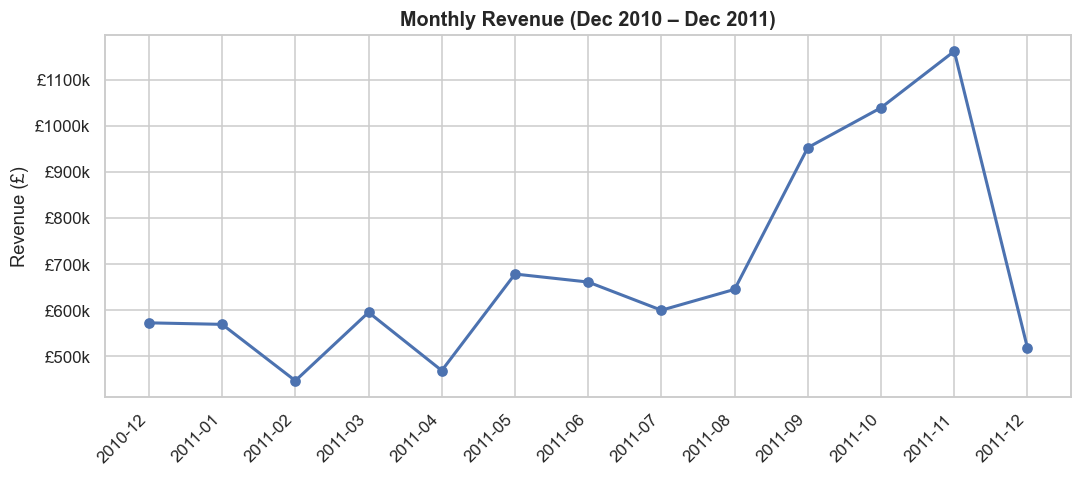

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(monthly_revenue["month"], monthly_revenue["revenue"], marker="o", linewidth=2)
ax.set_title("Monthly Revenue (Dec 2010 – Dec 2011)", fontsize=13, fontweight="bold")
ax.set_ylabel("Revenue (£)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1000:.0f}k"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/monthly_revenue.png", dpi=150)
plt.show()

Note the sharp Dec-2011 drop — the dataset simply ends mid-month, not a real decline.

### Revenue outside the UK (top 10 markets)

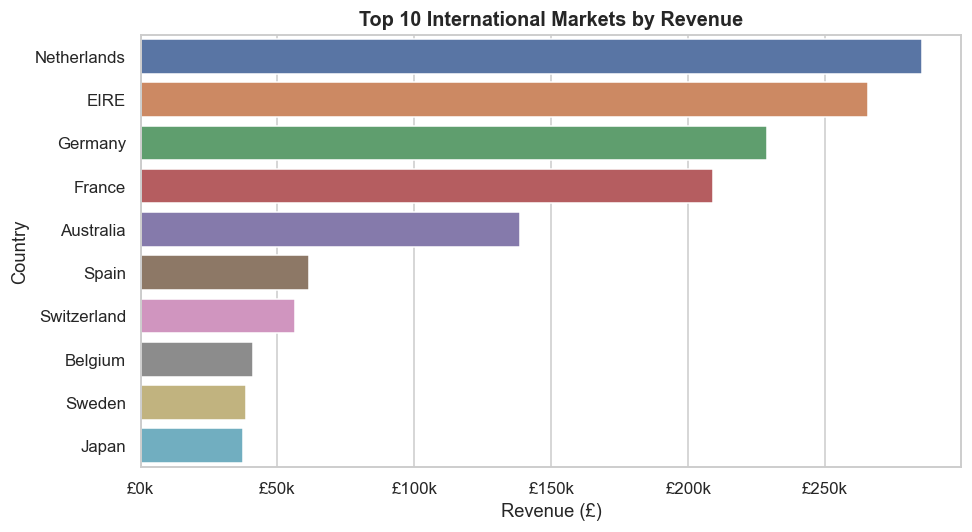

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top_countries, y="Country", x="revenue", hue="Country", legend=False, ax=ax)
ax.set_title("Top 10 International Markets by Revenue", fontsize=13, fontweight="bold")
ax.set_xlabel("Revenue (£)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1000:.0f}k"))
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/top_countries.png", dpi=150)
plt.show()

## 3. RFM feature engineering

For every customer: **Recency** (days since last purchase), **Frequency** (number of
distinct orders), **Monetary** (total spend). These three numbers compress a customer's
entire purchase history into a segmentable profile.

In [9]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = duckdb.query(f"""
    SELECT
        CustomerID,
        date_diff('day', MAX(InvoiceDate), TIMESTAMP '{snapshot_date}') AS Recency,
        COUNT(DISTINCT InvoiceNo) AS Frequency,
        ROUND(SUM(TotalPrice), 2) AS Monetary
    FROM df
    GROUP BY CustomerID
""").df().set_index("CustomerID")

rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,93.059474,4.272015,2054.266459
std,100.012264,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.750000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


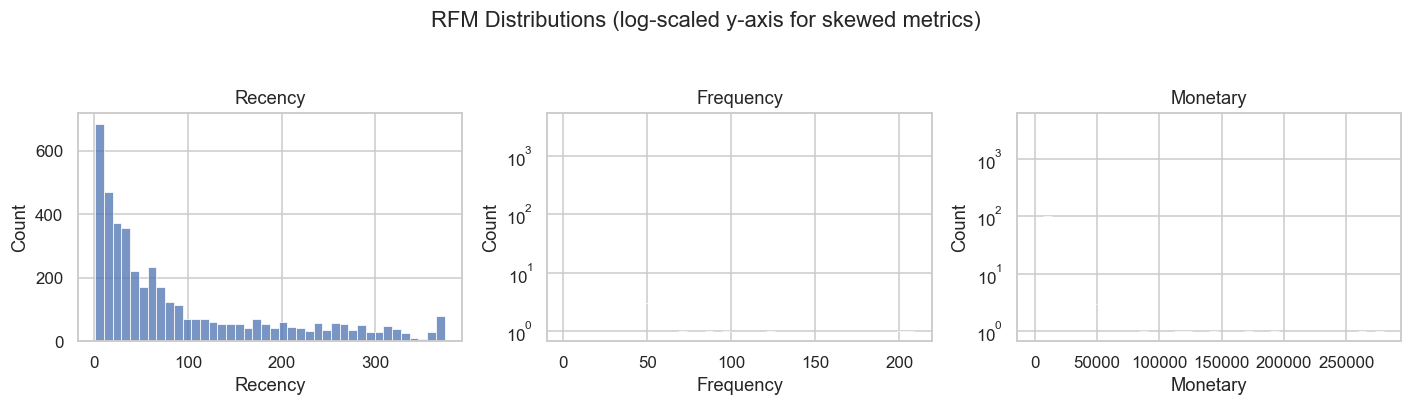

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.histplot(rfm[col], bins=40, ax=ax, log_scale=(False, True) if col != "Recency" else False)
    ax.set_title(col)
plt.suptitle("RFM Distributions (log-scaled y-axis for skewed metrics)", y=1.05)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/rfm_distributions.png", dpi=150)
plt.show()

## 4. Customer segmentation (KMeans)

RFM values are heavily right-skewed, so we log-transform before scaling — otherwise a
handful of huge spenders would dominate the distance metric KMeans uses.

In [11]:
rfm_log = rfm.copy()
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])
# Recency: smaller = more recent = better, keep as-is (already fairly well behaved)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[["Recency", "Frequency", "Monetary"]])

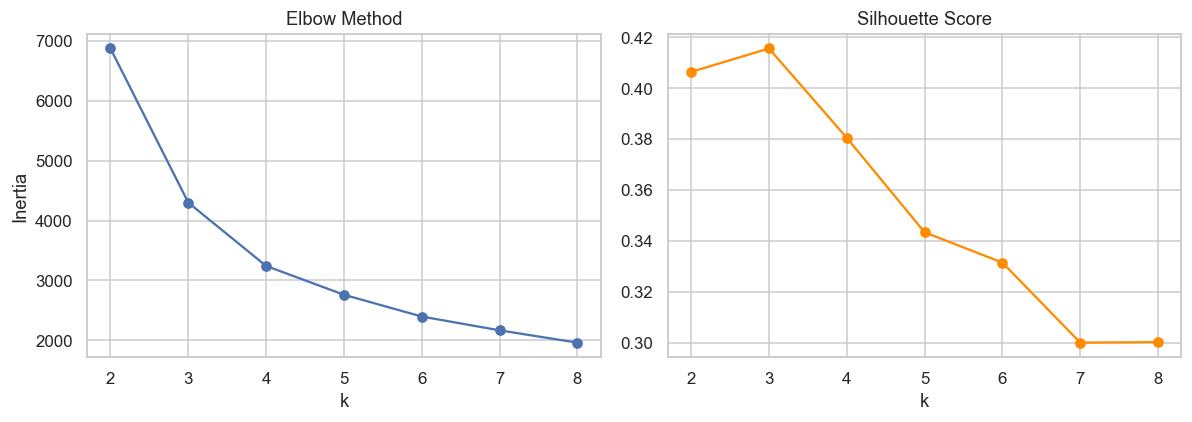

Best silhouette score at k=3


In [12]:
inertias, sil_scores = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/kmeans_selection.png", dpi=150)
plt.show()
print(f"Best silhouette score at k={list(k_range)[int(np.argmax(sil_scores))]}")

In [13]:
K = 4  # chosen for interpretability + strong silhouette score (see chart above)
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm["Segment"] = kmeans.fit_predict(rfm_scaled)

segment_profile = rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean().round(1)
segment_profile["CustomerCount"] = rfm.groupby("Segment").size()
segment_profile = segment_profile.sort_values("Monetary", ascending=False)
segment_profile

,Recency,Frequency,Monetary,CustomerCount
Segment,,,,
0,20.0,16.0,10007.5,558
3,46.1,4.3,1668.4,1448
2,58.7,1.5,393.2,1393
1,259.8,1.4,387.2,939


### Naming the segments

Ranking clusters by average Monetary value and Recency gives us business-readable names:

In [14]:
# Rank clusters: highest monetary + lowest recency = best customers
ranked = segment_profile.sort_values(["Monetary", "Recency"], ascending=[False, True]).index.tolist()
segment_names = {
    ranked[0]: "Champions",
    ranked[1]: "Loyal / Steady",
    ranked[2]: "At Risk",
    ranked[3]: "Lost / Low-Value",
}
rfm["SegmentName"] = rfm["Segment"].map(segment_names)
segment_profile["SegmentName"] = segment_profile.index.map(segment_names)
segment_profile

,Recency,Frequency,Monetary,CustomerCount,SegmentName
Segment,,,,,
0,20.0,16.0,10007.5,558,Champions
3,46.1,4.3,1668.4,1448,Loyal / Steady
2,58.7,1.5,393.2,1393,At Risk
1,259.8,1.4,387.2,939,Lost / Low-Value


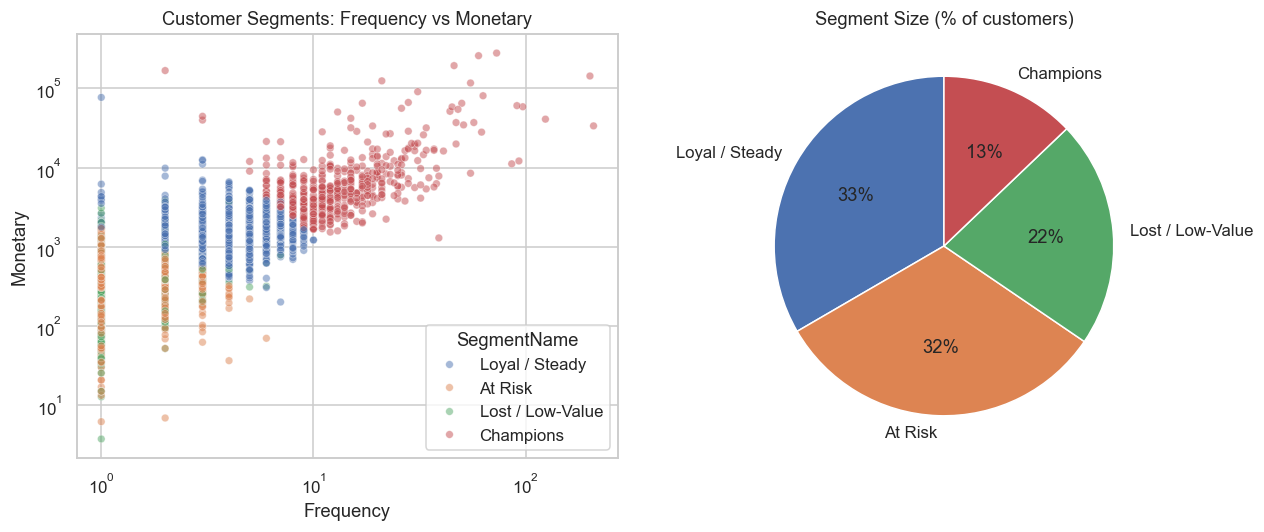

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order = segment_profile.sort_values("CustomerCount", ascending=False)["SegmentName"]
sns.scatterplot(
    data=rfm, x="Frequency", y="Monetary", hue="SegmentName", hue_order=order,
    alpha=0.5, s=25, ax=axes[0], palette="deep",
)
axes[0].set_yscale("log")
axes[0].set_xscale("log")
axes[0].set_title("Customer Segments: Frequency vs Monetary")

counts = rfm["SegmentName"].value_counts()
axes[1].pie(counts, labels=counts.index, autopct="%1.0f%%", startangle=90,
            colors=sns.color_palette("deep", len(counts)))
axes[1].set_title("Segment Size (% of customers)")

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/segments.png", dpi=150)
plt.show()

## 5. Cohort retention

Group customers by the month of their *first* purchase, then track what fraction of
each cohort is still buying in each subsequent month.

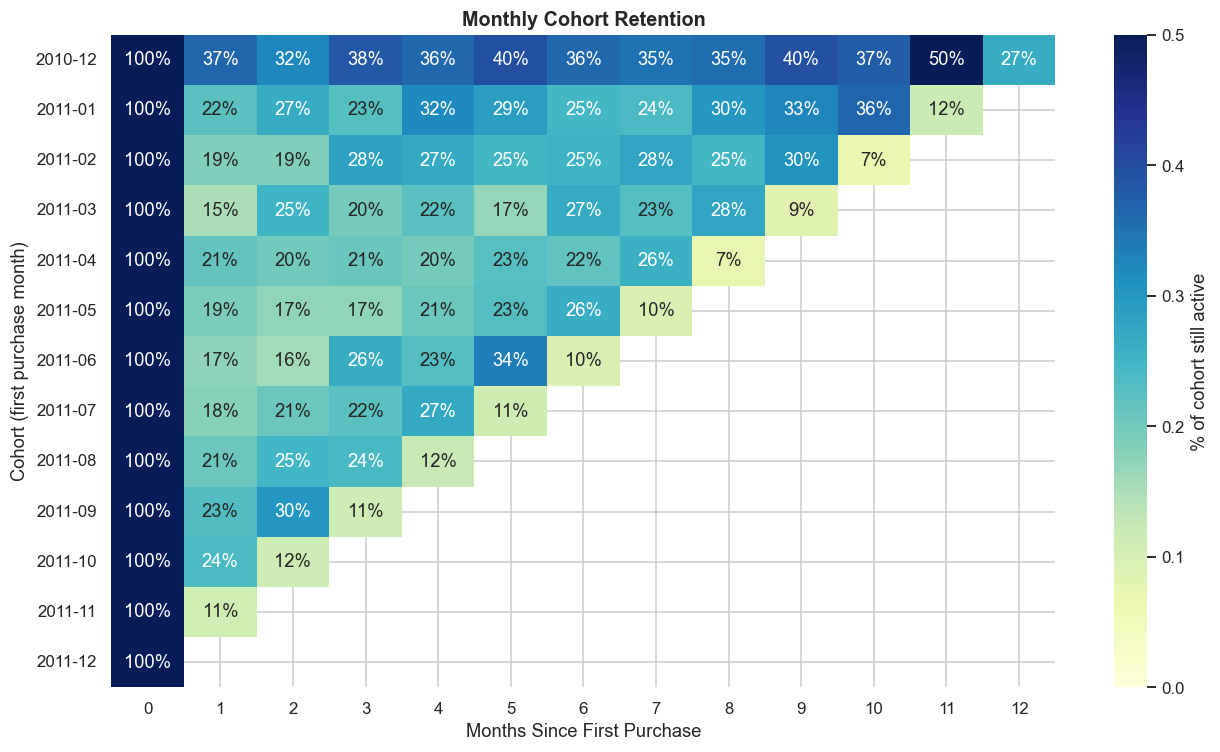

In [16]:
df["OrderMonth"] = df["InvoiceDate"].dt.to_period("M")
df["CohortMonth"] = df.groupby("CustomerID")["InvoiceDate"].transform("min").dt.to_period("M")
df["CohortIndex"] = (df["OrderMonth"] - df["CohortMonth"]).apply(lambda x: x.n)

cohort_data = df.groupby(["CohortMonth", "CohortIndex"])["CustomerID"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="CustomerID")
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="YlGnBu", vmin=0, vmax=0.5, ax=ax,
            cbar_kws={"label": "% of cohort still active"})
ax.set_title("Monthly Cohort Retention", fontsize=13, fontweight="bold")
ax.set_xlabel("Months Since First Purchase")
ax.set_ylabel("Cohort (first purchase month)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/cohort_retention.png", dpi=150)
plt.show()

Retention drops off hard after month 1 for most cohorts, then a subset of customers
settles into a steady repeat-purchase pattern — that steady group overlaps heavily
with the "Champions" / "Loyal" segments identified above.

## 6. Business recommendations

| Segment | Profile | Recommendation |
|---|---|---|
| **Champions** | Recent, frequent, high spend | Reward with early access / loyalty perks — protect this revenue base, they're the most valuable and easiest to retain |
| **Loyal / Steady** | Regular purchasers, moderate spend | Upsell/cross-sell campaigns to grow order value; nudge toward Champion tier |
| **At Risk** | Used to buy often, haven't purchased recently | Time-sensitive win-back offers before they churn fully — highest-leverage segment to act on |
| **Lost / Low-Value** | Long recency, low frequency/spend | Low-cost re-engagement (email) only; not worth heavy discounting given low historical value |

**Key numbers:**

In [17]:
summary = segment_profile[["SegmentName", "CustomerCount", "Recency", "Frequency", "Monetary"]]
summary["RevenueShare"] = (rfm.groupby("SegmentName")["Monetary"].sum() / rfm["Monetary"].sum()).reindex(summary["SegmentName"]).round(3).values
summary

/var/folders/4y/gfvp3jps5710ysvdz003nhnc0000gn/T/ipykernel_22110/1417959597.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary["RevenueShare"] = (rfm.groupby("SegmentName")["Monetary"].sum() / rfm["Monetary"].sum()).reindex(summary["SegmentName"]).round(3).values


,SegmentName,CustomerCount,Recency,Frequency,Monetary,RevenueShare
Segment,,,,,,
0,Champions,558,20.0,16.0,10007.5,0.627
3,Loyal / Steady,1448,46.1,4.3,1668.4,0.271
2,At Risk,1393,58.7,1.5,393.2,0.061
1,Lost / Low-Value,939,259.8,1.4,387.2,0.041
